# 10. Curvas de aprendizado observadas por Knowledge Component

Notebook da fase de *Modelling & Evaluation*. Constrói **curvas de aprendizado observadas no nível de conceito** a partir dos rótulos da Etapa 6 do pipeline KCGen-KT (Duan et al., 2025), entregando uma leitura **interpretável** de quais conceitos os estudantes aprendem e onde travam, em vez de uma leitura opaca por `ProblemID`.

**Contribuição central.** A camada semântica torna o estado de conhecimento comunicável para o docente: dizer que um estudante domina ou não "condições booleanas compostas" ou "iteração indexada" é pedagogicamente acionável, ao contrário de "acertou ou não o ProblemID 47". As curvas desta seção quantificam, por conceito, o ganho de acerto com a prática.

**Métrica primária: primeira tentativa.** Seguindo Shi et al. (2022) e a escolha já adotada no restante do trabalho (first-attempt AUC como métrica principal), a oportunidade primária é a **primeira tentativa em cada problema distinto** que exercita o conceito. Essa decisão evita o viés de autocorrelação das múltiplas tentativas (em que *retries* de um estudante que trava puxam a curva para baixo, medindo struggle e não aprendizado). A definição "todas as tentativas" entra apenas como contraste de robustez (Seção 8).

**Diferença em relação à projeção do Code-DKT.** O notebook 09 estima a *mastery prevista* por problema e a agrega por conceito. Aqui medimos **acerto observado** no nível de conceito: quando uma submissão erra, a Etapa 6 informa *qual* conceito falhou. A curva observada é um artefato de interpretabilidade mais confiável que a projeção do modelo, por ser medição e não extrapolação (ver Seção 7).

**Sobre a pergunta-título de Duan.** Duan et al. (2025) reportam que KCs gerados por LLM ajustam curvas de aprendizado melhor que KCs humanos. Testamos essa comparação contra o baseline ProblemID (Seção 5) e ela **não se reproduz no CSEDM**; tratamos o resultado como limitação, com a causa discutida (assimetria de oportunidade), sem que isso comprometa o valor de interpretabilidade da abordagem.

**Ressalvas de escopo (vinculantes).**

1. Análise **descritiva, não causal**: taxas de acerto observadas, não estados cognitivos.
2. Rótulos de erro por KC gerados por **LLM (Claude Haiku 4.5)**, não validados contra ground truth; validar essa fidelidade é tarefa do TCC 2.
3. Premissa de construção: **submissão correta implica todos os conceitos do problema demonstrados** (viés otimista, declarado).
4. A primeira tentativa por problema distinto é a definição **primária**; "todas as tentativas" é contraste (Seção 8).

## Configuração e dados de apoio

In [1]:
import json, pickle, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RES = ROOT / "results"
AIDS = [439, 487, 492, 494, 502]
MIN_N = 30           # mínimo de observações por ponto da curva
MAX_OPP_FIRST = 6    # oportunidades (primeira tentativa por problema distinto) — PRIMÁRIA
MAX_OPP_ALL = 8      # oportunidades (todas as tentativas) — contraste

BLUE, RED, GREEN, GREY = "#2667FF", "#d64550", "#2a9d5c", "#9aa0a6"

tr = json.load(open(RES / "kc_translations.json"))
CONCEPT_PT = {cid: c["pt"] for cid, c in tr["concepts"].items()}
name2cid = {n: v["concept_id"] for n, v in tr["translations"].items() if "concept_id" in v}

MARTINS = {
    "Estruturas de controle":          ["branching_condicional", "iteracao_indexada", "retorno_antecipado"],
    "Manipulação de variáveis":        ["padrao_acumulador", "inicializacao_variaveis", "estado_com_indices"],
    "Operadores e expressões lógicas": ["logica_booleana_composta", "negacao_booleana", "comparacao_numerica"],
    "Funções":                         ["metodos_auxiliares", "tipos_retorno", "parametros_metodo"],
    "Vetores":                         ["manipulacao_array", "bounds_checking", "dual_pointer"],
    "Conhecimento matemático":         ["operador_modulo", "aritmetica_condicional"],
}
print(f"{len(CONCEPT_PT)} conceitos semânticos | seed=42 | métrica primária: primeira tentativa")

28 conceitos semânticos | seed=42 | métrica primária: primeira tentativa


## 1. Carregamento

Sequências do Spring 2019 train (`sequences_bkt_dkt.pkl`, apenas `Run.Program`), rótulos da Etapa 6 (`kc_correctness_A*.json`, 5/5) e o mapa ProblemID para conjunto de conceitos (via Q-matrix e KCs canônicos).

In [2]:
artifact = pickle.load(open(RES / "sequences_bkt_dkt.pkl", "rb"))
kc_corr = {aid: json.load(open(RES / f"kc_correctness_A{aid}.json")) for aid in AIDS}

def build_concept_map(aid):
    qm = pd.read_csv(RES / f"qmatrix_A{aid}.csv").set_index("ProblemID")
    desc = {d["kc_id"]: d["name"] for d in json.load(open(RES / f"kc_descriptions_A{aid}.json"))}
    out = {}
    for pid in qm.index:
        s = set()
        for col in qm.columns:
            if qm.loc[pid, col] == 1:
                nm = desc.get(int(col.split("_")[1]))
                if nm and nm in name2cid:
                    s.add(name2cid[nm])
        out[pid] = s
    return out

cmap = {aid: build_concept_map(aid) for aid in AIDS}
n_lab = sum(len(c) for c in kc_corr.values())
print(f"sequências train: {sum(len(artifact['train'][a]) for a in AIDS)} | rótulos Etapa 6: {n_lab:,}")

sequências train: 1367 | rótulos Etapa 6: 30,747


## 2. Tabela de observações por conceito

Percorremos cada evento `Run.Program` do train em ordem temporal. Para cada conceito exigido pelo problema, definimos o acerto observado:

- **submissão correta** → todos os conceitos do problema demonstrados (`correct=1`);
- **submissão errada** → `kc_errors` da Etapa 6 define quais conceitos falharam (`correct=0`); os demais conceitos do problema contam como demonstrados.

Registramos as duas definições de oportunidade por observação:

- `opp_first` (**primária**): n-ésimo problema **distinto** que exercita o conceito, apenas primeira tentativa (padrão AFM, alinhado com Shi et al., 2022);
- `opp_all` (contraste): contagem cumulativa de prática do conceito (toda tentativa), usada apenas na Seção 8.

In [3]:
rows = []
for aid in AIDS:
    cc, cm = kc_corr[aid], cmap[aid]
    for seq in artifact["train"][aid]:
        sid = str(seq["subject_id"]); ev = seq["events"]
        opp_all = defaultdict(int)
        seen_prob = defaultdict(set)
        for _, r in ev.iterrows():
            pid = int(r["ProblemID"]); concepts = cm.get(pid, set())
            if not concepts:
                continue
            corr = int(r["correct"]); first = bool(r["is_first_attempt"])
            if corr == 1:
                fail = set()
            else:
                key = f"{sid}__{pid}__{str(r['CodeStateID'])}"
                kerr = cc.get(key, {}).get("kc_errors", {})
                fail = {name2cid[n] for n, f in kerr.items() if f == 1 and n in name2cid}
            for cid in concepts:
                c_ok = 0 if cid in fail else 1
                opp_all[cid] += 1
                is_new = first and pid not in seen_prob[cid]
                if is_new:
                    seen_prob[cid].add(pid)
                rows.append((aid, sid, cid, opp_all[cid],
                             len(seen_prob[cid]) if is_new else np.nan, c_ok))

obs = pd.DataFrame(rows, columns=["aid", "sid", "cid", "opp_all", "opp_first", "correct"])
print(f"observações: {len(obs):,} | conceitos: {obs.cid.nunique()} | "
      f"primeiras tentativas (opp_first): {obs.opp_first.notna().sum():,}")

observações: 173,809 | conceitos: 28 | primeiras tentativas (opp_first): 49,462


### 2.1 Baseline ProblemID (para a Seção 5)

Mesma estrutura com o KC sendo o `ProblemID` (protocolo Shi et al., 2022). Como cada problema é seu próprio KC, ele só acumula oportunidades por **retentativas**, então o baseline existe apenas na definição "todas as tentativas". É usado somente na limitação da Seção 5.

In [4]:
rows_pid = []
for aid in AIDS:
    for seq in artifact["train"][aid]:
        sid = str(seq["subject_id"]); ev = seq["events"]
        opp = defaultdict(int)
        for _, r in ev.iterrows():
            pid = int(r["ProblemID"])
            opp[pid] += 1
            rows_pid.append((aid, sid, pid, opp[pid], int(r["correct"])))
obs_pid = pd.DataFrame(rows_pid, columns=["aid", "sid", "pid", "opp", "correct"])
print(f"observações ProblemID: {len(obs_pid):,} | problemas: {obs_pid.pid.nunique()}")

observações ProblemID: 43,110 | problemas: 50


## 3. Curvas de aprendizado observadas por conceito (primeira tentativa)

Agregamos a taxa de acerto por oportunidade (mínimo de 30 observações por ponto) e ajustamos dois modelos clássicos:

- **AFM-logit**: `logit(p) = a + b·oportunidade`; `b > 0` indica aprendizado. R² no espaço logit.
- **Power law of practice**: `taxa_de_erro = A·oportunidade^(-β)`, em log-log; `β > 0` indica erro decrescente.

A definição é a **primária** (`opp_first`). Os conceitos que sobrevivem são os que recorrem como primeira tentativa em ao menos três problemas distintos; eles são bem-povoados (centenas de observações por ponto).

In [5]:
def curve_points(g, opp_col, max_opp):
    pts = []
    for n in range(1, max_opp + 1):
        sub = g[g[opp_col] == n]
        if len(sub) >= MIN_N:
            pts.append((n, float(sub.correct.mean()), int(len(sub))))
    return pts

def fit_afm(pts):
    ns = np.array([p[0] for p in pts], float)
    ps = np.clip(np.array([p[1] for p in pts], float), .01, .99)
    logit = np.log(ps / (1 - ps))
    b, a = np.polyfit(ns, logit, 1)
    pred = a + b * ns
    r2 = 1 - ((logit - pred) ** 2).sum() / (((logit - logit.mean()) ** 2).sum() + 1e-9)
    return float(b), float(r2)

def fit_power(pts):
    ns = np.array([p[0] for p in pts], float)
    err = np.clip(1 - np.array([p[1] for p in pts], float), .01, .99)
    lo, le = np.log(ns), np.log(err)
    b, a = np.polyfit(lo, le, 1)
    pred = a + b * lo
    r2 = 1 - ((le - pred) ** 2).sum() / (((le - le.mean()) ** 2).sum() + 1e-9)
    return float(-b), float(r2)

def build_curves(df, opp_col, max_opp, group="cid"):
    out = {}
    for k, g in df.groupby(group):
        pts = curve_points(g, opp_col, max_opp)
        if len(pts) < 3:
            continue
        b_afm, r2_afm = fit_afm(pts)
        beta, r2_pow = fit_power(pts)
        out[k] = {"points": pts, "p_at_1": round(pts[0][1], 4), "p_at_last": round(pts[-1][1], 4),
                  "slope_afm": round(b_afm, 4), "r2_afm": round(r2_afm, 3),
                  "beta_power": round(beta, 4), "r2_power": round(r2_pow, 3),
                  "n_total": int(sum(p[2] for p in pts)), "n_per_point_min": int(min(p[2] for p in pts))}
    return out

curves_first = build_curves(obs.dropna(subset=["opp_first"]), "opp_first", MAX_OPP_FIRST)  # PRIMÁRIA
curves_all = build_curves(obs, "opp_all", MAX_OPP_ALL)  # contraste (Seção 8)

tbl = pd.DataFrame([
    {"conceito": CONCEPT_PT[c], "p@1": v["p_at_1"], "p@últ": v["p_at_last"],
     "incl_AFM": v["slope_afm"], "R²_AFM": v["r2_afm"], "β_power": v["beta_power"],
     "R²_power": v["r2_power"], "N_mín/pt": v["n_per_point_min"], "N": v["n_total"]}
    for c, v in curves_first.items()]).sort_values("incl_AFM", ascending=False)
n_pos = sum(v["slope_afm"] > 0 for v in curves_first.values())
print(f"conceitos com curva (primeira tentativa): {len(curves_first)} | "
      f"inclinação positiva (aprendizado): {n_pos}/{len(curves_first)}")
print(f"inclinação AFM mediana: {np.median([v['slope_afm'] for v in curves_first.values()]):+.3f} | "
      f"R²_AFM mediano: {np.median([v['r2_afm'] for v in curves_first.values()]):.3f}")
tbl.reset_index(drop=True)

conceitos com curva (primeira tentativa): 13 | inclinação positiva (aprendizado): 10/13
inclinação AFM mediana: +0.103 | R²_AFM mediano: 0.526


,conceito,p@1,p@últ,incl_AFM,R²_AFM,β_power,R²_power,N_mín/pt,N
0,Validação de múltiplas restrições com operador...,0.3696,0.8019,0.9661,0.935,1.0585,0.999,207,705
1,Retorno antecipado em controle de fluxo,0.6614,0.8582,0.3136,0.877,0.6254,0.915,268,3050
2,Expressões booleanas compostas com operadores ...,0.7410,0.9476,0.2623,0.435,0.5415,0.313,286,3661
3,Branching condicional multi-caminho,0.6396,0.8381,0.2544,0.768,0.5584,0.830,488,4351
4,Tipos e formato de retorno de método,0.7393,0.8416,0.1112,0.627,0.2722,0.741,461,4955
5,Comparação numérica e thresholds,0.6488,0.7278,0.1104,0.362,0.2198,0.323,507,3243
6,Iteração indexada e controle de loop,0.5891,0.6807,0.1033,0.526,0.1940,0.501,476,4177
7,Negação booleana com operador NOT,0.6784,0.7329,0.0947,0.731,0.1232,0.547,277,1850
8,Manipulação de strings,0.6165,0.7265,0.0906,0.324,0.1415,0.248,234,2323
9,Manipulação de arrays,0.6687,0.7477,0.0282,0.047,0.0891,0.116,432,2809


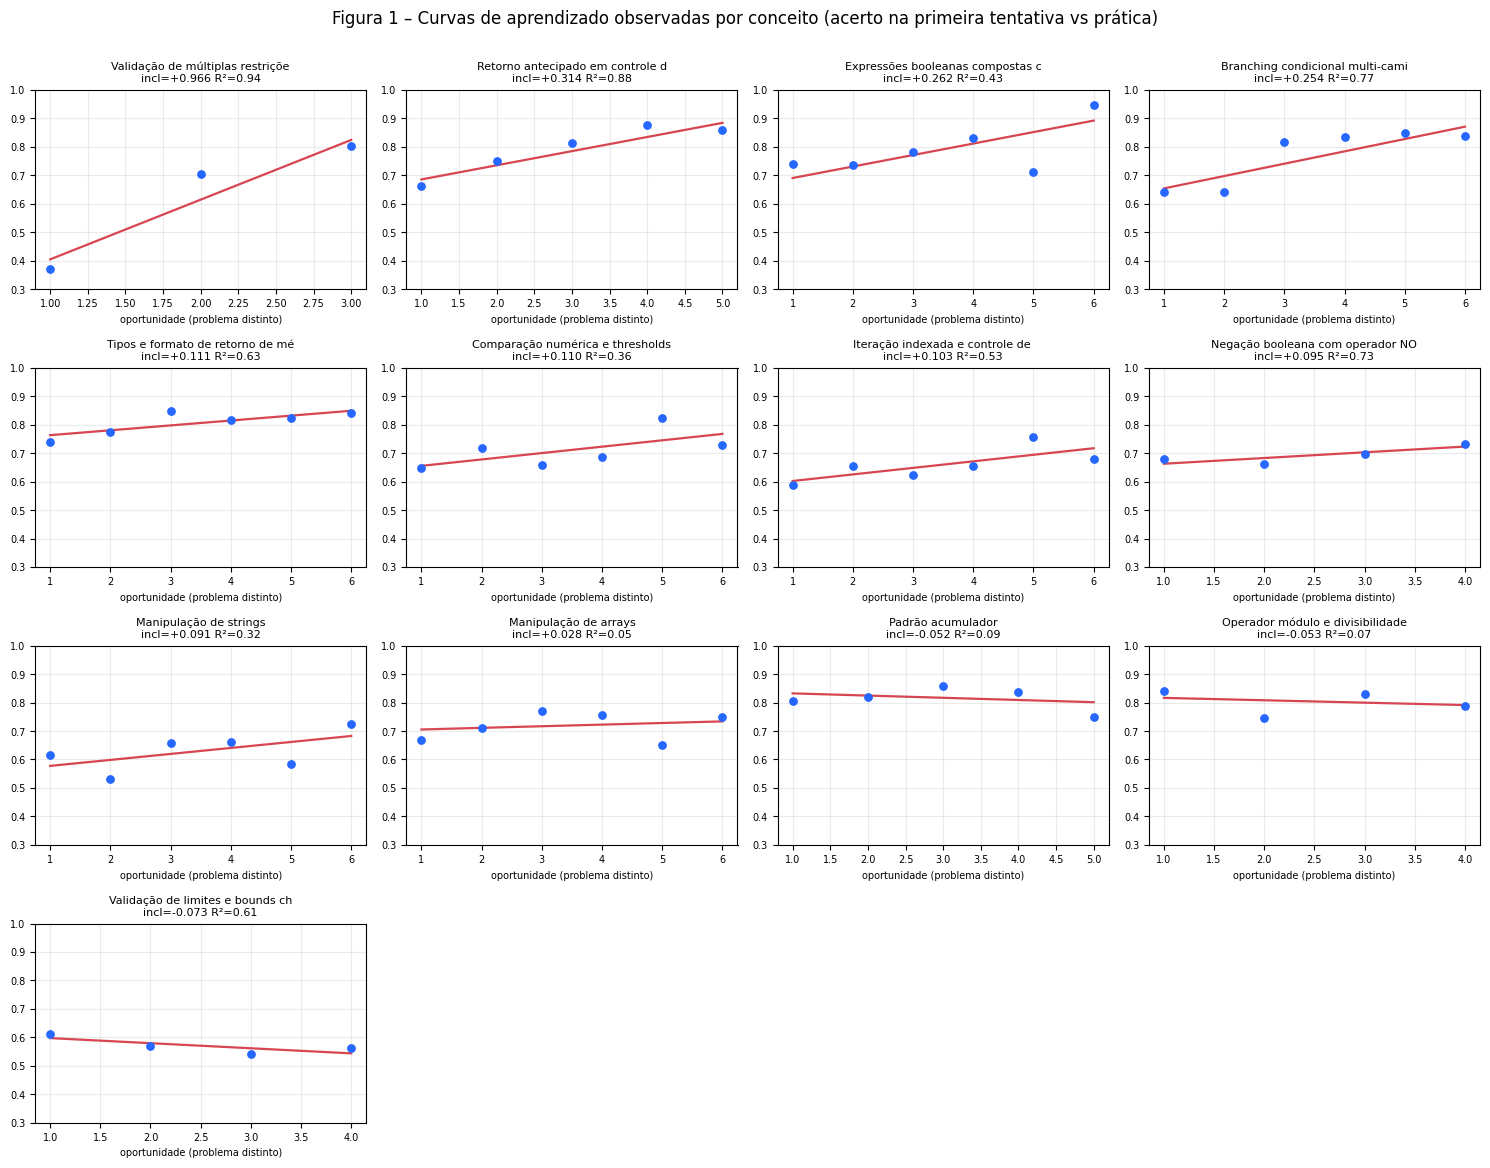

Fonte: elaborado pelo autor (2026).


In [6]:
# Figura 1: curvas observadas por conceito (primeira tentativa)
items = sorted(curves_first.items(), key=lambda kv: kv[1]["slope_afm"], reverse=True)
cols = 4; rows_ = (len(items) + cols - 1) // cols
fig, axes = plt.subplots(rows_, cols, figsize=(15, 2.9 * rows_))
axes = np.array(axes).reshape(-1)
for ax, (cid, c) in zip(axes, items):
    ns = [p[0] for p in c["points"]]; ps = [p[1] for p in c["points"]]
    ax.scatter(ns, ps, color=BLUE, s=28, zorder=3)
    xs = np.array([min(ns), max(ns)], float)
    b, a = np.polyfit(np.array(ns, float),
                      np.log(np.clip(ps, .01, .99)) - np.log(1 - np.clip(ps, .01, .99)), 1)
    ax.plot(xs, 1 / (1 + np.exp(-(a + b * xs))), color=RED, lw=1.6)
    ax.set_title(f"{CONCEPT_PT[cid][:32]}\nincl={c['slope_afm']:+.3f} R²={c['r2_afm']:.2f}", fontsize=8)
    ax.set_ylim(0.3, 1.0); ax.tick_params(labelsize=7); ax.grid(alpha=.25)
    ax.set_xlabel("oportunidade (problema distinto)", fontsize=7)
for ax in axes[len(items):]:
    ax.axis("off")
fig.suptitle("Figura 1 – Curvas de aprendizado observadas por conceito (acerto na primeira tentativa vs prática)",
             fontsize=12, y=1.003)
fig.tight_layout()
fig.savefig(RES / "fig_pfa_curves.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fonte: elaborado pelo autor (2026).")

## 4. Baseline ProblemID (ajuste por retentativa)

Para a comparação da Seção 5, ajustamos as curvas com KC = `ProblemID` na definição "todas as tentativas" (única possível para o ProblemID). A oportunidade é a contagem de tentativas no problema, então a curva mede convergência *intra-problema* (o estudante retenta até passar).

In [7]:
curves_pid = build_curves(obs_pid, "opp", MAX_OPP_ALL, group="pid")
pid_tbl = pd.DataFrame([
    {"ProblemID": k, "p@1": v["p_at_1"], "p@últ": v["p_at_last"],
     "incl_AFM": v["slope_afm"], "R²_AFM": v["r2_afm"], "N": v["n_total"]}
    for k, v in curves_pid.items()]).sort_values("R²_AFM", ascending=False)
print(f"problemas com curva: {len(curves_pid)}")
pid_tbl.reset_index(drop=True).head(12)

problemas com curva: 50


,ProblemID,p@1,p@últ,incl_AFM,R²_AFM,N
0,44,0.5681,0.4583,-0.2205,0.993,355
1,57,0.7235,0.3871,-0.7107,0.987,315
2,36,0.4646,0.2432,-0.1916,0.958,647
3,233,0.4118,0.2121,-0.1574,0.891,774
4,48,0.4703,0.2258,-0.2640,0.790,552
5,17,0.6710,0.3030,-0.4640,0.776,399
6,1,0.5139,0.5476,0.0432,0.737,553
7,64,0.4798,0.2258,-0.2111,0.717,602
8,21,0.6340,0.5000,-0.2748,0.690,375
9,12,0.6276,0.4318,-0.3982,0.688,446


## 5. Limitação: replicação da comparação de Duan (semântico vs ProblemID)

Duan et al. (2025) reportam que KCs gerados por LLM ajustam curvas de aprendizado melhor que KCs humanos. Aqui testamos a versão análoga: o R² do ajuste AFM dos conceitos semânticos supera o dos `ProblemID`?

**Restrição metodológica.** O ProblemID só forma curva na definição "todas as tentativas" (cada problema é um KC isolado, sem recorrência entre problemas). Para a comparação ser possível, os conceitos também entram com "todas as tentativas". O teste é **Mann-Whitney U** (distribuições independentes, unidades diferentes).

**Assimetria de oportunidade.** A curva do ProblemID mede convergência intra-problema (retentativas até passar, forte e regular), enquanto a do conceito mede transferência entre problemas (mais ruidosa). A comparação é estruturalmente enviesada a favor do ProblemID, então um empate ou derrota do semântico **não** indica ausência de valor, apenas que essa métrica específica não favorece a granularidade semântica neste dataset.

R²_AFM mediano (todas as tentativas) | conceito semântico: 0.452 (n=28)
R²_AFM mediano (todas as tentativas) | ProblemID baseline: 0.461 (n=50)
Mann-Whitney U (semântico > ProblemID): U=673, p=0.6127
>> Conclusão: a vantagem de Duan NÃO se reproduz no CSEDM


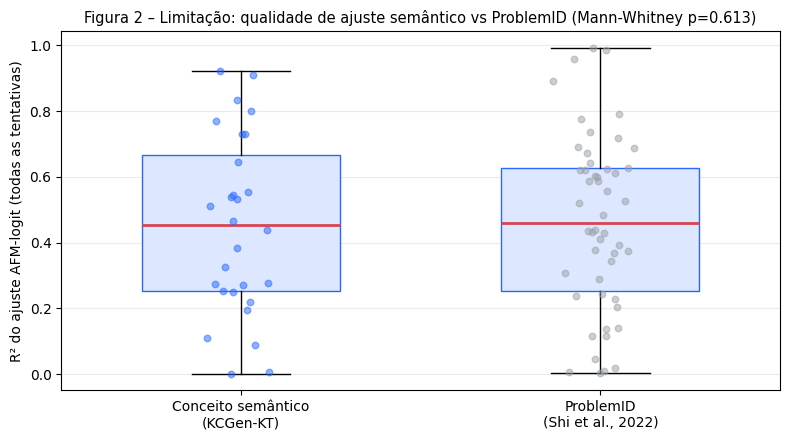

Fonte: elaborado pelo autor (2026).


In [8]:
r2_concept_all = [v["r2_afm"] for v in curves_all.values()]
r2_problem = [v["r2_afm"] for v in curves_pid.values()]
U, p = stats.mannwhitneyu(r2_concept_all, r2_problem, alternative="greater")
print(f"R²_AFM mediano (todas as tentativas) | conceito semântico: {np.median(r2_concept_all):.3f} (n={len(r2_concept_all)})")
print(f"R²_AFM mediano (todas as tentativas) | ProblemID baseline: {np.median(r2_problem):.3f} (n={len(r2_problem)})")
print(f"Mann-Whitney U (semântico > ProblemID): U={U:.0f}, p={p:.4f}")
print(">> Conclusão:", "semântico ajusta melhor (p<0,05)" if p < 0.05 else "a vantagem de Duan NÃO se reproduz no CSEDM")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.boxplot([r2_concept_all, r2_problem], labels=["Conceito semântico\n(KCGen-KT)", "ProblemID\n(Shi et al., 2022)"],
           widths=.55, patch_artist=True,
           boxprops=dict(facecolor="#dde7ff", color=BLUE), medianprops=dict(color=RED, lw=2))
ax.scatter(np.random.normal(1, .05, len(r2_concept_all)), r2_concept_all, color=BLUE, alpha=.5, s=22, zorder=3)
ax.scatter(np.random.normal(2, .05, len(r2_problem)), r2_problem, color=GREY, alpha=.5, s=22, zorder=3)
ax.set_ylabel("R² do ajuste AFM-logit (todas as tentativas)")
ax.set_title(f"Figura 2 – Limitação: qualidade de ajuste semântico vs ProblemID (Mann-Whitney p={p:.3f})", fontsize=10.5)
ax.grid(axis="y", alpha=.25)
fig.tight_layout()
fig.savefig(RES / "fig_pfa_semantic_vs_problemid.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fonte: elaborado pelo autor (2026).")

## 6. Agregação por sub-dificuldade de Martins, Marin e Alves (2024)

Agregamos a inclinação observada (primeira tentativa) e o nível inicial por grupo de dificuldade de Martins, ligando o resultado interpretável aos slides da apresentação.

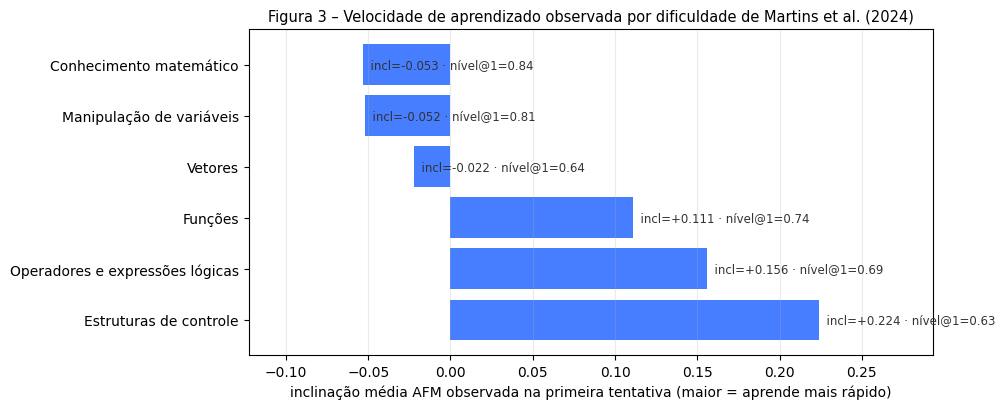

Fonte: elaborado pelo autor (2026).
conceitos cobertos por Martins (primeira tentativa): 11


,mean_slope_afm,mean_level_at_1,n_concepts,concepts
Estruturas de controle,0.2238,0.63,3,"[Branching condicional multi-caminho, Iteração..."
Manipulação de variáveis,-0.0519,0.8066,1,[Padrão acumulador]
Operadores e expressões lógicas,0.1558,0.6894,3,[Expressões booleanas compostas com operadores...
Funções,0.1112,0.7393,1,[Tipos e formato de retorno de método]
Vetores,-0.0224,0.6401,2,"[Manipulação de arrays, Validação de limites e..."
Conhecimento matemático,-0.0533,0.8409,1,[Operador módulo e divisibilidade]


In [9]:
by_martins = {}
for grp, cids in MARTINS.items():
    sl = [curves_first[c]["slope_afm"] for c in cids if c in curves_first]
    lv = [curves_first[c]["p_at_1"] for c in cids if c in curves_first]
    present = [CONCEPT_PT[c] for c in cids if c in curves_first]
    if sl:
        by_martins[grp] = {"mean_slope_afm": round(float(np.mean(sl)), 4),
                           "mean_level_at_1": round(float(np.mean(lv)), 4),
                           "n_concepts": len(sl), "concepts": present}

gm = sorted(by_martins.items(), key=lambda kv: kv[1]["mean_slope_afm"])
labels = [g for g, _ in gm]; slopes = [v["mean_slope_afm"] for _, v in gm]; levels = [v["mean_level_at_1"] for _, v in gm]
fig, ax = plt.subplots(figsize=(10, 4.2))
yp = np.arange(len(labels))
ax.barh(yp, slopes, color=BLUE, alpha=.85)
ax.set_yticks(yp); ax.set_yticklabels(labels, fontsize=10); ax.invert_yaxis()
ax.set_xlabel("inclinação média AFM observada na primeira tentativa (maior = aprende mais rápido)")
ax.set_title("Figura 3 – Velocidade de aprendizado observada por dificuldade de Martins et al. (2024)", fontsize=10.5)
for i, (b, lv) in enumerate(zip(slopes, levels)):
    ax.text(b, i, f"  incl={b:+.3f} · nível@1={lv:.2f}", va="center", fontsize=8.5, color="#333")
ax.grid(axis="x", alpha=.25); ax.margins(x=.25)
fig.tight_layout()
fig.savefig(RES / "fig_pfa_martins.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fonte: elaborado pelo autor (2026).")
print(f"conceitos cobertos por Martins (primeira tentativa): {sum(v['n_concepts'] for v in by_martins.values())}")
pd.DataFrame(by_martins).T

## 7. Validação: a dificuldade prevista pelo Code-DKT bate com a observada?

Esta seção valida o uso do **modelo** para o caso de uso do docente. O professor não quer um retrato do semestre passado; quer saber **quais conceitos estão difíceis agora** para decidir o que reforçar. Isso é uma tarefa prospectiva, e quem a resolve é o modelo (roda sobre a turma atual sem precisar dos resultados futuros), não a curva observada (que é retrospectiva e depende dos resultados já terem ocorrido e de o LLM rotular os erros).

Comparamos, por conceito, a estimativa do Code-DKT com o acerto observado (Etapa 6, primeira tentativa), em duas dimensões:

- **Nível (dificuldade)**: chance de acerto na primeira oportunidade. É a dimensão sobre a qual o docente age.
- **Inclinação (velocidade de aprendizado)**: o quão rápido o acerto cresce com a prática. Dimensão secundária.

**Caveat de split.** A projeção foi medida no *test set*; a curva observada usa o *train* (único onde a Etapa 6 rotulou). Comparamos populações por oportunidade, não pareamento por estudante.

NÍVEL/dificuldade (o que o docente age):  ρ=0.725, p=0.005 (n=13)
INCLINAÇÃO/velocidade de aprendizado:     ρ=0.225, p=0.459
>> O modelo prevê BEM a dificuldade dos conceitos (dimensão acionável)


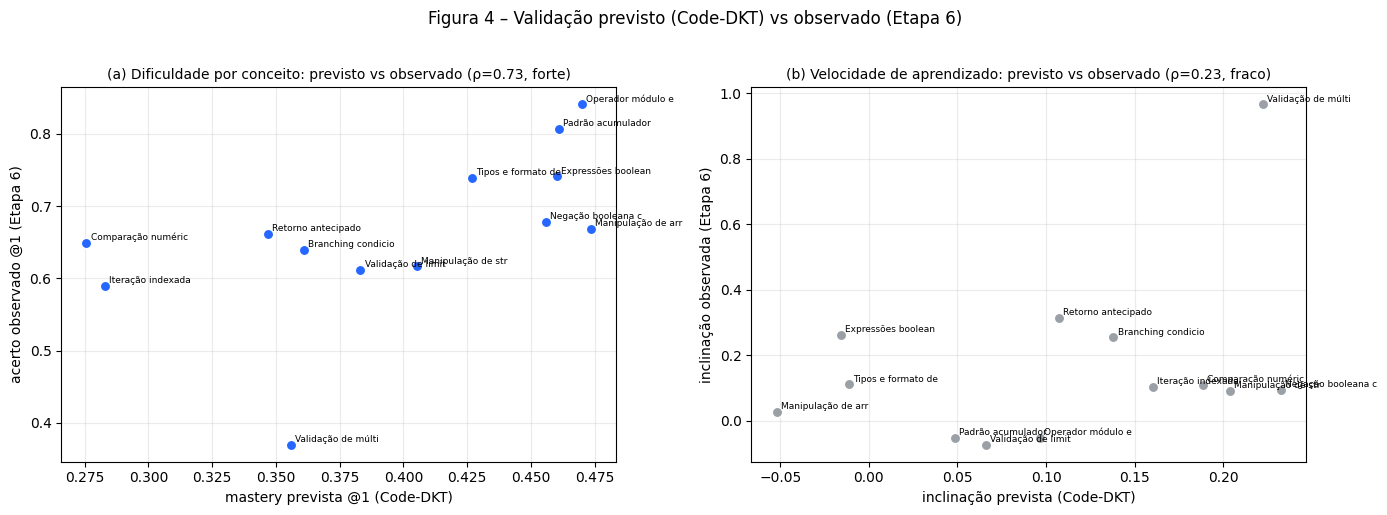

Fonte: elaborado pelo autor (2026).


,conceito,obs_nivel,pred_nivel,obs_incl,pred_incl
0,Validação de limites e bounds checking,0.611,0.383,-0.073,0.066
1,Branching condicional multi-caminho,0.640,0.361,0.254,0.138
2,Comparação numérica e thresholds,0.649,0.276,0.110,0.188
3,Iteração indexada e controle de loop,0.589,0.283,0.103,0.160
4,Expressões booleanas compostas com operadores ...,0.741,0.460,0.262,-0.016
5,Manipulação de arrays,0.669,0.474,0.028,-0.052
6,Manipulação de strings,0.616,0.405,0.091,0.204
7,Negação booleana com operador NOT,0.678,0.456,0.095,0.232
8,Operador módulo e divisibilidade,0.841,0.470,-0.053,0.097
9,Padrão acumulador,0.807,0.461,-0.052,0.049


In [10]:
proj = json.load(open(RES / "codedkt_kc_difficulty.json"))["curves"]
comp = []
for cid, c in curves_first.items():
    if cid in proj and proj[cid].get("pred_at_1") is not None:
        comp.append({"conceito": CONCEPT_PT[cid],
                     "obs_nivel": c["p_at_1"], "pred_nivel": proj[cid]["pred_at_1"],
                     "obs_incl": c["slope_afm"], "pred_incl": proj[cid]["slope_afm"]})
comp_df = pd.DataFrame(comp)
rho_lvl = p_lvl = rho_slp = p_slp = float("nan")
if len(comp_df) >= 3:
    rho_lvl, p_lvl = stats.spearmanr(comp_df.pred_nivel, comp_df.obs_nivel)
    rho_slp, p_slp = stats.spearmanr(comp_df.pred_incl, comp_df.obs_incl)
    print(f"NÍVEL/dificuldade (o que o docente age):  ρ={rho_lvl:.3f}, p={p_lvl:.3f} (n={len(comp_df)})")
    print(f"INCLINAÇÃO/velocidade de aprendizado:     ρ={rho_slp:.3f}, p={p_slp:.3f}")
    print(">> O modelo prevê BEM a dificuldade dos conceitos (dimensão acionável)" if p_lvl < 0.05
          else ">> O modelo não prevê bem a dificuldade")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.scatter(comp_df.pred_nivel, comp_df.obs_nivel, color=BLUE, s=55, zorder=3, edgecolor="white")
for _, r in comp_df.iterrows():
    ax.annotate(r["conceito"][:18], (r["pred_nivel"], r["obs_nivel"]), fontsize=6.5,
                xytext=(3, 2), textcoords="offset points")
ax.set_xlabel("mastery prevista @1 (Code-DKT)"); ax.set_ylabel("acerto observado @1 (Etapa 6)")
ax.set_title(f"(a) Dificuldade por conceito: previsto vs observado (ρ={rho_lvl:.2f}, forte)", fontsize=10)
ax.grid(alpha=.25)
ax = axes[1]
ax.scatter(comp_df.pred_incl, comp_df.obs_incl, color=GREY, s=55, zorder=3, edgecolor="white")
for _, r in comp_df.iterrows():
    ax.annotate(r["conceito"][:18], (r["pred_incl"], r["obs_incl"]), fontsize=6.5,
                xytext=(3, 2), textcoords="offset points")
ax.set_xlabel("inclinação prevista (Code-DKT)"); ax.set_ylabel("inclinação observada (Etapa 6)")
ax.set_title(f"(b) Velocidade de aprendizado: previsto vs observado (ρ={rho_slp:.2f}, fraco)", fontsize=10)
ax.grid(alpha=.25)
fig.suptitle("Figura 4 – Validação previsto (Code-DKT) vs observado (Etapa 6)", fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig(RES / "fig_pfa_pred_vs_obs.png", dpi=130, bbox_inches="tight")
plt.show()
print("Fonte: elaborado pelo autor (2026).")
comp_df.round(3)

## 8. Robustez: contraste com "todas as tentativas"

Reexecutamos com a oportunidade `opp_all` (todas as tentativas), que inclui *retries*. Esperamos curvas mais achatadas ou negativas (struggle), confirmando *por que* a primeira tentativa é a definição primária. Verificamos também se a ordenação relativa dos conceitos se mantém entre as duas definições (consistência interna).

In [11]:
sl_first = [v["slope_afm"] for v in curves_first.values()]
sl_all = [v["slope_afm"] for v in curves_all.values()]
print(f"inclinação AFM mediana | primeira tentativa: {np.median(sl_first):+.3f} "
      f"({sum(s>0 for s in sl_first)}/{len(sl_first)} positivas)")
print(f"inclinação AFM mediana | todas as tentativas: {np.median(sl_all):+.3f} "
      f"({sum(s>0 for s in sl_all)}/{len(sl_all)} positivas)  <- struggle dos retries")

rob = pd.DataFrame([
    {"conceito": CONCEPT_PT[c], "incl_first": curves_first[c]["slope_afm"],
     "incl_all": curves_all[c]["slope_afm"] if c in curves_all else np.nan}
    for c in curves_first]).dropna()
rho2, p2 = stats.spearmanr(rob.incl_first, rob.incl_all)
print(f"\nSpearman inclinação primeira-tentativa vs todas-tentativas: ρ={rho2:.3f}, p={p2:.3f} (n={len(rob)})")
print(">> ordenação relativa", "consistente" if p2 < 0.05 else "não consistente", "entre as definições")
rob.round(3).sort_values("incl_first", ascending=False).reset_index(drop=True)

inclinação AFM mediana | primeira tentativa: +0.103 (10/13 positivas)
inclinação AFM mediana | todas as tentativas: -0.030 (9/28 positivas)  <- struggle dos retries

Spearman inclinação primeira-tentativa vs todas-tentativas: ρ=0.687, p=0.010 (n=13)
>> ordenação relativa consistente entre as definições


,conceito,incl_first,incl_all
0,Validação de múltiplas restrições com operador...,0.966,0.082
1,Retorno antecipado em controle de fluxo,0.314,0.014
2,Expressões booleanas compostas com operadores ...,0.262,-0.007
3,Branching condicional multi-caminho,0.254,0.035
4,Tipos e formato de retorno de método,0.111,0.049
5,Comparação numérica e thresholds,0.110,0.040
6,Iteração indexada e controle de loop,0.103,0.027
7,Negação booleana com operador NOT,0.095,-0.028
8,Manipulação de strings,0.091,-0.044
9,Manipulação de arrays,0.028,0.036


## 9. Quebra por assignment

Inspeção por assignment. Como a primeira tentativa por assignment é esparsa (poucos conceitos recorrem em ≥3 problemas dentro de um único assignment), esta visão usa "todas as tentativas", apenas para inspeção da variação entre os cinco contextos.

In [12]:
per_aid = []
for aid in AIDS:
    ca = build_curves(obs[obs.aid == aid], "opp_all", MAX_OPP_ALL)
    if ca:
        per_aid.append({"assignment": f"A{aid}", "n_conceitos": len(ca),
                        "incl_AFM_média": round(float(np.mean([v["slope_afm"] for v in ca.values()])), 4),
                        "R²_AFM_médio": round(float(np.mean([v["r2_afm"] for v in ca.values()])), 3),
                        "nível@1_médio": round(float(np.mean([v["p_at_1"] for v in ca.values()])), 3)})
pd.DataFrame(per_aid)

,assignment,n_conceitos,incl_AFM_média,R²_AFM_médio,nível@1_médio
0,A439,9,0.0674,0.481,0.691
1,A487,13,-0.0104,0.305,0.599
2,A492,11,-0.0379,0.360,0.674
3,A494,14,-0.0080,0.286,0.682
4,A502,10,-0.0463,0.515,0.716


## 10. Síntese e persistência

In [13]:
payload = {
    "params": {"min_n": MIN_N, "max_opp_first": MAX_OPP_FIRST, "max_opp_all": MAX_OPP_ALL, "seed": 42},
    "primary": "first_attempt",
    "curves_first": curves_first, "curves_all": curves_all, "curves_pid": curves_pid,
    "duan_comparison_limitation": {"r2_concept_all_median": float(np.median(r2_concept_all)),
                                   "r2_problem_median": float(np.median(r2_problem)),
                                   "mannwhitney_U": float(U), "mannwhitney_p": float(p)},
    "pred_vs_obs": {"nivel_rho": float(rho_lvl), "nivel_p": float(p_lvl), "incl_rho": float(rho_slp), "incl_p": float(p_slp), "n": int(len(comp_df))},
    "by_martins": by_martins,
}
json.dump(payload, open(RES / "pfa_curves.json", "w"), ensure_ascii=False, indent=2)
print("salvo: results/pfa_curves.json + 4 figuras")

salvo: results/pfa_curves.json + 4 figuras


### Síntese narrativa para o documento do TCC

A Etapa 6 do pipeline KCGen-KT permitiu medir o aprendizado **no nível de conceito** a partir do acerto observado na primeira tentativa. As curvas da Seção 3 mostram que a maioria dos conceitos apresenta aprendizado mensurável e se ordena de forma interpretável pela dificuldade de Martins, Marin e Alves (2024) na Seção 6.

O resultado central para a aplicação está na Seção 7: a **dificuldade que o Code-DKT prevê concorda fortemente com a observada** (Spearman ρ=0,73, p<0,01), embora o modelo seja ruidoso ao prever a *velocidade* de aprendizado (ρ=0,23, n.s.). Como o docente age sobre *quais conceitos estão difíceis agora*, e não sobre a velocidade, essa validação sustenta usar a estimativa do modelo, prospectiva e aplicável à turma atual, como a peça de interpretabilidade entregue ao professor. A curva observada cumpre aqui o papel de **validação** dessa estimativa.

A comparação direta da pergunta-título de Duan et al. (2025), se KCs semânticos ajustam curvas melhor que o baseline ProblemID, **não se reproduz no CSEDM** (Seção 5), o que atribuímos à assimetria de oportunidade (ProblemID converge por retentativa intra-problema) e à baixa recorrência de conceitos em um currículo de poucos problemas por assignment. A validação da fidelidade dos rótulos gerados por LLM, condição para uso confiável em sala, fica como agenda do TCC 2.